# 11. Live Polymarket Senate market research

Discover 2026 U.S. Senate election contracts, inspect settlement compatibility, and screen conditional model–price gaps. Includes Senate race winners, margins, relative results, control, seat totals and Senate-only combinations. Other offices, turnout, primaries and market-price targets are excluded. **Research only: no orders, wallet, keys or account access.**

This notebook reads the last verified live forecast. It does not refresh election sources or train models. A failed or unresolved election-source review in notebook04 is not repaired by market prices. Check forecast freshness and roster assumptions before interpreting a gap.

[Method and limitations](../docs/POLYMARKET_RESEARCH.md) · [Latest report](../outputs/reports/markets/polymarket/report.md) · [Daily archive](../outputs/reports/history/README.md)

In [2]:
from pathlib import Path
import sys, importlib, json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'election_lab.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import election_lab as lab
import live_polymarket as poly
importlib.reload(poly)
import polymarket_scanner as scanner
importlib.reload(scanner)
from model_labels import label_frame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_seq_items', None)

OFFLINE = False
REFRESH_EXTERNAL = True  # Independently refresh public forecasts; no model inference.
FORCE_EXTERNAL = False  # Publisher cache: six hours.
MAX_EXTERNAL_AGE_DAYS = 3
REFRESH_MARKETS = True  # False reuses a saved market snapshot without network calls.
FORCE_CATALOG = False  # Public catalog cache: 15 minutes. Order books refresh each online run.
ILLUSTRATIVE_SHARES = 100  # Depth calculation, not a suggested trade size.
MIN_MODELED_GAP_PP = 3
MAX_BID_ASK_SPREAD = .10
MIN_REPORTED_LIQUIDITY = 2000
MAX_FORECAST_AGE_DAYS = 3
RUN = lab.latest_run('live')
print('Verified forecast:', RUN.relative_to(ROOT))
print('Forecast cutoff:', json.loads((RUN/'run.json').read_text())['as_of'])
import polymarket_debug_view as debug_view
importlib.reload(debug_view)
from IPython.display import HTML

def show_details(frame, title):
    display(HTML(debug_view.CSS + '<div class="scan"><details><summary>' + title +
        f' ({len(frame)} rows)</summary>' + debug_view.small_html(frame) + '</details></div>'))


Verified forecast: cache/runs/live/20260925T165454.221722Z
Forecast cutoff: 2026-09-25


### Prepare local simulations when needed

Git keeps compact forecast results and saved model parameters. Full simulation draws are local-only. On a fresh clone, this separate step recreates them from the exact saved inputs and verifies unchanged predictions and seat probabilities. It downloads nothing and does not retrain historical models. Later scans reuse the local draws.

In [3]:
from export_predictive_distributions import ensure_full_samples
RUN = lab.run_logged(ensure_full_samples, RUN)
print('Local forecast simulations ready:', RUN.relative_to(ROOT))

Run log: cache/logs/ensure_full_samples_20260925T190903.126340Z.txt
Local forecast simulations ready: cache/runs/live/20260925T165454.221722Z


## 1. Discover and retrieve public market data

All pages of the Midterms, US Elections, Senate Midterms and Senate Elections tags are scanned and deduplicated. New markets are discovered on catalog refresh. This is a transparent catalog scope, not a guarantee that every untagged contract is found. Failed catalog refreshes are visibly stale; offline mode never produces live quotes.

Only Senate election outcomes are retained. An event groups related contracts. Each margin band counts as one contract; its Yes and No tokens are not counted separately. Hundreds of contracts do not mean hundreds of Senate races.

In [4]:
# Download step: rerun when market prices change. No model inference.
MARKET_SNAPSHOT = poly.download_markets(offline=OFFLINE, force=FORCE_CATALOG) if REFRESH_MARKETS else poly.load_market_snapshot()
print('Market snapshot:', MARKET_SNAPSHOT['retrieved_at'])
print('Order books:', MARKET_SNAPSHOT['book_status'])

Market snapshot: 2026-09-25T19:09:34.228613+00:00
Order books: {'status': 'checked online', 'errors': [], 'retrieved_at': '2026-09-25T19:09:34.228584+00:00', 'tokens_requested': 990, 'books_returned': 990}


### Refresh external forecasts independently

Race to the WH supplies state winners and Senate-control odds. DDHQ also supplies a seat-count histogram. This download does not rerun our models or refresh market prices. Set `REFRESH_EXTERNAL = False` to reuse the saved publisher snapshot. Independent candidate probabilities are not added to Democratic-party contracts.

In [5]:
import polymarket_external as external_models
importlib.reload(external_models)
EXTERNAL_FORECASTS = external_models.load(offline=OFFLINE or not REFRESH_EXTERNAL, force=FORCE_EXTERNAL)
print(external_models.METHOD)
display(HTML(debug_view.CSS + '<div class="scan">' + debug_view.small_html(external_models.status_table(EXTERNAL_FORECASTS)) + '</div>'))

RTWH and DDHQ are separate published forecasts, not new mixture components. They use the same ask depth, fees and sensitivity stresses as our models. Their displayed probabilities are point estimates, not confidence bounds; no state margin distribution is invented. DDHQ uses market inputs where disclosed, so its agreement with prices is not independent evidence. Publisher dates are independent of our forecast cutoff. Failed refreshes and forecasts older than the age limit are unpriced. Independent candidates stay separate from Democrats. Chamber comparisons remain conditional on publisher caucus conventions. Silver public commentary and Inside Elections ratings remain in notebook 04; they are not numerical state models here.


Model,Published,Refresh,Race records,Note
RTWH,2026-09-25,recent publisher cache,35,State winners/control; no margin distribution.
DDHQ,2026-09-25,recent publisher cache,35,Seat histogram available. Includes market inputs.


### Evaluate the saved forecast against this market snapshot

This step makes no network calls and does not rerun model inference. Rerun it and the following cells after changing the forecast or scan settings. Set `REFRESH_MARKETS = False` to reuse a snapshot during Run All. Old quotes are identified and excluded from live candidates.

In [6]:
from predictive_distributions import FORMULAS
display(Markdown(FORMULAS))

The code maps supported contract types to explicit events. It does not hardcode a probability for each market.

| Contract | Yes probability |
|---|---|
| Democratic winner | P(D minus R margin > 0) |
| Republican winner | 1 minus P(D minus R margin > 0) |
| Democratic margin from a to b | P(a <= margin < b) |
| Republican margin from a to b | P(-b < margin <= -a) |
| Democratic Senate control | P(D/Independent seats >= 51) |
| Republican Senate control | P(D/Independent seats <= 50) |
| Republican seat total | Sum of saved seat probabilities satisfying the stated exact/at-least/at-most condition |
| Buy No | 1 minus the corresponding Yes probability |

Gaussian state events use its analytic CDF. Student-t and mixture state events count matching full simulations, with saved component weights for mixtures. Chamber events use saved joint seat frequencies, preserving state dependence. Simulation estimates have Monte Carlo error; zero observed events does not prove impossibility. No quantile interpolation or Gaussian approximation of the Student-t/mixture is used. Unrecognized or incompatible settlement rules remain unpriced.


In [7]:
research = poly.analyze(RUN, snapshot=MARKET_SNAPSHOT, offline=OFFLINE, shares=ILLUSTRATIVE_SHARES,
    min_edge_pp=MIN_MODELED_GAP_PP, max_spread=MAX_BID_ASK_SPREAD,
    min_liquidity=MIN_REPORTED_LIQUIDITY, max_forecast_age_days=MAX_FORECAST_AGE_DAYS)
show_details(pd.DataFrame([research['status']]).drop(columns='book_status').T.rename(columns={0:'Value'}).rename_axis('Setting').reset_index(), 'Source and run details')
print(research['status']['book_status'])
scanner.display_full(poly.inventory_summary(research))

Setting,Value
retrieved_at,2026-09-25T19:09:34.228613+00:00
evaluated_at,2026-09-25T19:09:35.199600+00:00
catalog_status,checked online
catalog_age_seconds,6.16
max_catalog_age_seconds,900
max_book_age_seconds,120
forecast_cutoff,2026-09-25
forecast_age_days,0
forecast_manifest_sha256,0632f06aac571c2fee3d30bd0866d15704f29b06e905c4bb449e96917f01afd6
forecast_source_review,full_online_final_poll_review


{'status': 'checked online', 'errors': [], 'retrieved_at': '2026-09-25T19:09:34.228584+00:00', 'tokens_requested': 990, 'books_returned': 990}


category,events,contracts,reported_liquidity
Senate margins / relative results,39,394,3037734.53
Senate race winners,35,79,4137174.84
Senate seat counts,1,11,333458.92
Senate-only combinations,2,9,100544.65
Senate control,1,2,878686.18


## 2. Complete searchable inventory

Every discovered active Senate-outcome contract is retained in `inventory`, including contracts we cannot price. Change `CATEGORY` or `SEARCH` to inspect any Senate race, margin band, control, seat total or Senate-only combination. The report links every discovered event. The Gamma indicative price is a catalog quote, not an executable price.

In [8]:
inventory = research['inventory']
CATEGORY = None  # Set to None for all categories.
SEARCH = ''  # Example: Texas, Margin, seats, Combo.
selection = inventory.copy()
if CATEGORY: selection = selection[selection.category.eq(CATEGORY)]
if SEARCH: selection = selection[selection.event.str.contains(SEARCH, case=False, regex=False) | selection.question.str.contains(SEARCH, case=False, regex=False)]
print(f'{len(selection)} matching contracts; all {len(inventory)} remain in inventory and saved files.')
show_details(selection[['question','outcome','indicative_yes','liquidity']].rename(columns={'question':'Market','outcome':'Outcome','indicative_yes':'Price','liquidity':'Liquidity'}), 'Market inventory')

495 matching contracts; all 495 remain in inventory and saved files.


Market,Outcome,Price,Liquidity
Will the Democratic Party control the Senate after the 2026 Midterm elections?,Democratic Party,0.62,465390.22
Will the Republican Party control the Senate after the 2026 Midterm elections?,Republican Party,0.38,413295.96
Will the Democrats win the Alabama Senate race in 2026?,Everett Wess (D),0.02,12489.91
Will the Republicans win the Alabama Senate race in 2026?,Barry Moore (R),0.97,11223.31
Will the Democrats win the Arkansas Senate race in 2026?,Hallie Shoffner (D),0.06,18834.38
Will the Republicans win the Arkansas Senate race in 2026?,Tom Cotton (R),0.95,40387.58
Will the Democrats win the Colorado Senate race in 2026?,John Hickenlooper (D),0.98,16976.12
Will the Republicans win the Colorado Senate race in 2026?,Mark Baisley (R),0.02,21534.06
Will the Democrats win the Delaware Senate race in 2026?,Democrat,0.99,17598.53
Will the Republicans win the Delaware Senate race in 2026?,Republican,0.01,28605.35


## 3. Margin contracts and settlement mappings

Gaussian probabilities use the analytic distribution. Student-t and mixture probabilities use full saved simulations. No quantile-based bounds are used. First-round outcomes, incompatible candidate rules, and unsupported joint/ranking contracts remain unpriced. The full audit records the event formula and probability method for every supported contract.


In [9]:
margins = inventory[inventory.category.eq('Senate margins / relative results')]
show_details(margins[['question','model_low','model_high','reason']].rename(columns={'question':'Market','model_low':'P low','model_high':'P high','reason':'Reason'}), 'Margin compatibility details')
show_details(inventory.groupby(['category','mapping','reason']).size().rename('Contracts').reset_index(), 'Coverage by contract type')

Market,P low,P high,Reason
Will Alaska have the closest Senate race in 2026?,—,—,No compatible party-specific margin distribution for this independent or multi-round contest.
Will Montana have the closest Senate race in 2026?,—,—,No compatible party-specific margin distribution for this independent or multi-round contest.
Will Colorado have the closest Senate race in 2026?,—,—,No compatible party-specific margin distribution for this independent or multi-round contest.
Will New Mexico have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band
Will Texas have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band
Will Nebraska have the closest Senate race in 2026?,—,—,No compatible party-specific margin distribution for this independent or multi-round contest.
Will Iowa have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band
Will Minnesota have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band
Will Michigan have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band
Will Ohio (Special) have the closest Senate race in 2026?,—,—,Margin/ranking contract is not a recognized party-specific margin band


category,mapping,reason,Contracts
Senate control,Conditional comparison,"Assumes modeled independent winners caucus with Democrats, the existing fixed-seat roster, and GOP 50-seat tie-break; contract waits for caucus declarations",2
Senate margins / relative results,Conditional comparison,Assumes D/R are the top two and forecast margin uses the same vote denominator; full predictive distribution is used,180
Senate margins / relative results,Not priced,First-round contract is not the final-election forecast,38
Senate margins / relative results,Not priced,Margin/ranking contract is not a recognized party-specific margin band,46
Senate margins / relative results,Not priced,Multiple states or unrecognized geography; joint/relative outcome requires a separate model,11
Senate margins / relative results,Not priced,No compatible party-specific margin distribution for this independent or multi-round contest.,119
Senate race winners,Conditional comparison,Assumes modeled D/R contenders exhaust the winning outcomes; party replacements and third-party wins require review.,42
Senate race winners,Conditional settlement proxy,Candidate roster is unreviewed; this assumes the modeled D/R sides match the party nominees.,12
Senate race winners,Conditional settlement proxy,Ranked-choice transfers are not separately modeled; the modeled margin is used as a proxy for the eventual winner.,4
Senate race winners,Conditional settlement proxy,Runoff transfers and turnout are not separately modeled; the modeled margin is used as a proxy for the eventual winner.,2


## 4. Conditional research candidates

For each eligible Yes **and** No token, read its own order book, sort ask levels, and estimate the cost of the configured share quantity including the published taker-fee schedule. The minimum modeled gap uses the model probability. Missing fees/books, partial fills, wide spreads, low liquidity, stale catalogs and old forecasts prevent shortlisting.

Every result still requires settlement and model review. A model–price gap is not arbitrage. Multiple contracts can represent the same correlated election risk. Senate-control and seat-count comparisons depend on our independent-caucus assumptions; joint outcomes are not inferred from marginal Senate probabilities.

In [10]:
mixture_columns = ['Contract','Outcome','Model probability %','Cost incl. fees (¢)','Minimum modeled gap (pp)']
mixture_checks = poly.comparison_table(research, only_shortlist=False, limit=len(research['comparisons']))
show_details(mixture_checks[[c for c in mixture_columns if c in mixture_checks]] if 'Contract' in mixture_checks else mixture_checks, 'Mixture-only reference comparisons')


Contract,Outcome,Model probability %,Cost incl. fees (¢),Minimum modeled gap (pp)
Will the Democratic Party candidate win the 2026 Rhode Island Senate election by 30% or more?,No,78.5,42.97,35.51
Will Mary Peltola win the Alaska Senate race in 2026?,No,60.0,28.81,31.23
Will Dan Sullivan win the Alaska Senate race in 2026?,Yes,60.0,29.82,30.22
Will the Republican Party candidate win the 2026 Kentucky Senate election by 0%-10%?,Yes,34.2,9.96,24.21
Will the Republicans win the Kansas Senate race in 2026?,Yes,89.4,70.84,18.55
Will the Democrats win the Kansas Senate race in 2026?,No,89.4,70.84,18.55
Will the Republican Party candidate win the 2026 Kansas Senate election by 5%-10%?,Yes,35.4,18.59,16.77
Will the Republicans win the Maine Senate race in 2026?,No,85.5,68.87,16.67
Will the Democrats win the Maine Senate race in 2026?,Yes,85.5,69.86,15.69
Will the Democratic Party candidate win the 2026 New Mexico Senate election by 21% or more?,No,76.4,62.94,13.41


## 5. All model-market pairs, grouped by market
All qualifying markets appear below. Each market keeps every model and both Yes/No sides together in one compact, color-coded table. Model abbreviations are explained once at the top. There are no dropdowns or combined model scores.


RTWH and DDHQ appear as separate rows. Each uses its own published probability and the same fees, depth and stress assumptions. Missing public distributions remain unavailable. Dates and publisher-specific limitations appear beneath each market.

A status marked `*` is a conditional settlement estimate. Its P, EV and stress depend on the stated runoff, ranked-choice or candidate assumptions. These rows are amber. Exact limitations and unavailable mappings are explained below each table.

In [11]:
import polymarket_scanner as scanner
importlib.reload(scanner)
STRESS_FRICTION_CENTS = 2.0  # Extra cost only in the stress scenario; base EV uses depth + fees.
PROBABILITY_HAIRCUT_PP = 2.0  # Separate sensitivity stress, not calibrated confidence.
INITIAL_MIN_EDGE_PP = 0.0
research['scanner'] = scanner.scan(research, RUN, friction_cents=STRESS_FRICTION_CENTS,
    probability_haircut_pp=PROBABILITY_HAIRCUT_PP, min_edge_pp=INITIAL_MIN_EDGE_PP,
    external=EXTERNAL_FORECASTS, max_external_age_days=MAX_EXTERNAL_AGE_DAYS)
print('Base budget/EV: ask-depth purchase cost plus estimated taker fees.')
print(f'Stress only: +{STRESS_FRICTION_CENTS:g} cents/share and -{PROBABILITY_HAIRCUT_PP:g} percentage points from the model probability.')
import polymarket_debug_view as debug_view
importlib.reload(debug_view)
debug_view.display(research['scanner'])
audit = label_frame(research['scanner']['audit'].groupby(['model','mapping','reason']).size().rename('N').reset_index())
audit['model'] = research['scanner']['audit'].groupby(['model','mapping','reason']).size().reset_index()['model'].map(lambda name: debug_view.MODEL_CODES.get(name, name))
show_details(audit.rename(columns={'model':'Model','mapping':'Status','reason':'Explanation'}), 'Coverage audit (counts, not profit)')


Base budget/EV: ask-depth purchase cost plus estimated taker fees.
Stress only: +2 cents/share and -2 percentage points from the model probability.


172 markets. Every model and both sides are grouped under each market.


/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

Model,Status,Explanation,N
GB,Conditional comparison,Assumes D/R are the top two and forecast margin uses the same vote denominator; full predictive distribution is used,180
GB,Conditional comparison,Assumes R seats equal 100 minus modeled D/Independent seats; caucus choices and vacancies may differ from contract,11
GB,Conditional comparison,Assumes modeled D/R contenders exhaust the winning outcomes; party replacements and third-party wins require review.,42
GB,Conditional comparison,"Assumes modeled independent winners caucus with Democrats, the existing fixed-seat roster, and GOP 50-seat tie-break; contract waits for caucus declarations",2
GB,Conditional settlement proxy,Candidate roster is unreviewed; this assumes the modeled D/R sides match the party nominees.,12
GB,Conditional settlement proxy,Ranked-choice transfers are not separately modeled; the modeled margin is used as a proxy for the eventual winner.,4
GB,Conditional settlement proxy,Runoff transfers and turnout are not separately modeled; the modeled margin is used as a proxy for the eventual winner.,2
GB,Conditional settlement proxy,The strongest D/Independent-versus-R margin approximates the winning side; third-candidate outcomes are not jointly modeled. Independents remain IND.,6
GB,Not priced,First-round contract is not the final-election forecast,38
GB,Not priced,Margin/ranking contract is not a recognized party-specific margin band,46


## 6. Model-free price mismatches
Check equal-size Yes and No purchases on the same contract after fees and friction on both legs. This is separate from model value. Every checked contract is displayed below.

In [12]:
import polymarket_price_checks as price_checks
importlib.reload(price_checks)
research['price_checks'] = price_checks.scan_pairs(research, friction_cents=0.0)
research['price_checks_stress'] = price_checks.scan_pairs(research, friction_cents=STRESS_FRICTION_CENTS)
print(price_checks.METHOD)
print('Contracts checked:', len(research['price_checks']))
print('Base snapshot candidates (depth + fees):', int(research['price_checks'].candidate.sum()))
print('Extra-friction scenario candidates:', int(research['price_checks_stress'].candidate.sum()))
pair_view = price_checks.table(research['price_checks'], limit=len(research['price_checks']))
show_details(pair_view[['Contract','Cost of both sides ($)','Normal combined payout ($)','Snapshot payoff less cost ($)','Status']], 'Same-contract price checks')


This check buys equal quantities of Yes and No on the same binary contract. Their combined settlement payout is $1 per pair under normal settlement. A snapshot mismatch exists only when ask-depth costs, taker fees and friction on BOTH legs total less than $1. This does not use an election model. It is not an executable guarantee: both legs must fill, quotes can change, and settlement/platform risk remains. Other relationships, such as winner versus margin bands or seat totals versus control, are not tested without verified matching settlement rules.
Contracts checked: 495
Base snapshot candidates (depth + fees): 0
Extra-friction scenario candidates: 0


Contract,Cost of both sides ($),Normal combined payout ($),Snapshot payoff less cost ($),Status
Will the Democrats win the South Dakota Senate race in 2026?,100.11,100,-0.11,No positive mismatch after costs
Will the Democratic Party candidate win the 2026 Rhode Island Senate election by 5%-10%?,100.12,100,-0.12,Blocked
Will the Republican Party hold exactly 56 Senate seats after the 2026 midterm elections?,100.22,100,-0.22,Blocked
Will the Democratic Party candidate win the 2026 Virginia Senate election by 0%-3%?,100.26,100,-0.26,Blocked
Will the Republicans win the Wyoming Senate race in 2026?,100.34,100,-0.34,No positive mismatch after costs
Will the Republican Party hold 57 or more Senate seats after the 2026 midterm elections?,100.34,100,-0.34,No positive mismatch after costs
Will Colorado have the closest Senate race in 2026?,100.37,100,-0.37,No positive mismatch after costs
Will the Democratic Party candidate win the 2026 Virginia Senate election by 3%-6%?,100.38,100,-0.38,No positive mismatch after costs
Will the Democratic Party candidate win the 2026 Idaho Senate election?,100.43,100,-0.43,No positive mismatch after costs
Will the Democrats win the Montana Senate race in 2026?,100.43,100,-0.43,No positive mismatch after costs


## 7. Charts and dated report

Run All saves a compact, reproducible report with the entire catalog, rule snapshots, exclusions, fee/depth calculations and provenance. Raw discovery downloads stay in the ignored cache. The daily report replaces only the same UTC date, preserving earlier days.

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_debug_view.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if g.status.eq('Unavailable').any() or ('settlement_proxy' in g and g.settlement_proxy.fillna(False).any()):
/Users/amir/projects/small_models/us_election_2026/scripts/polymarket_de

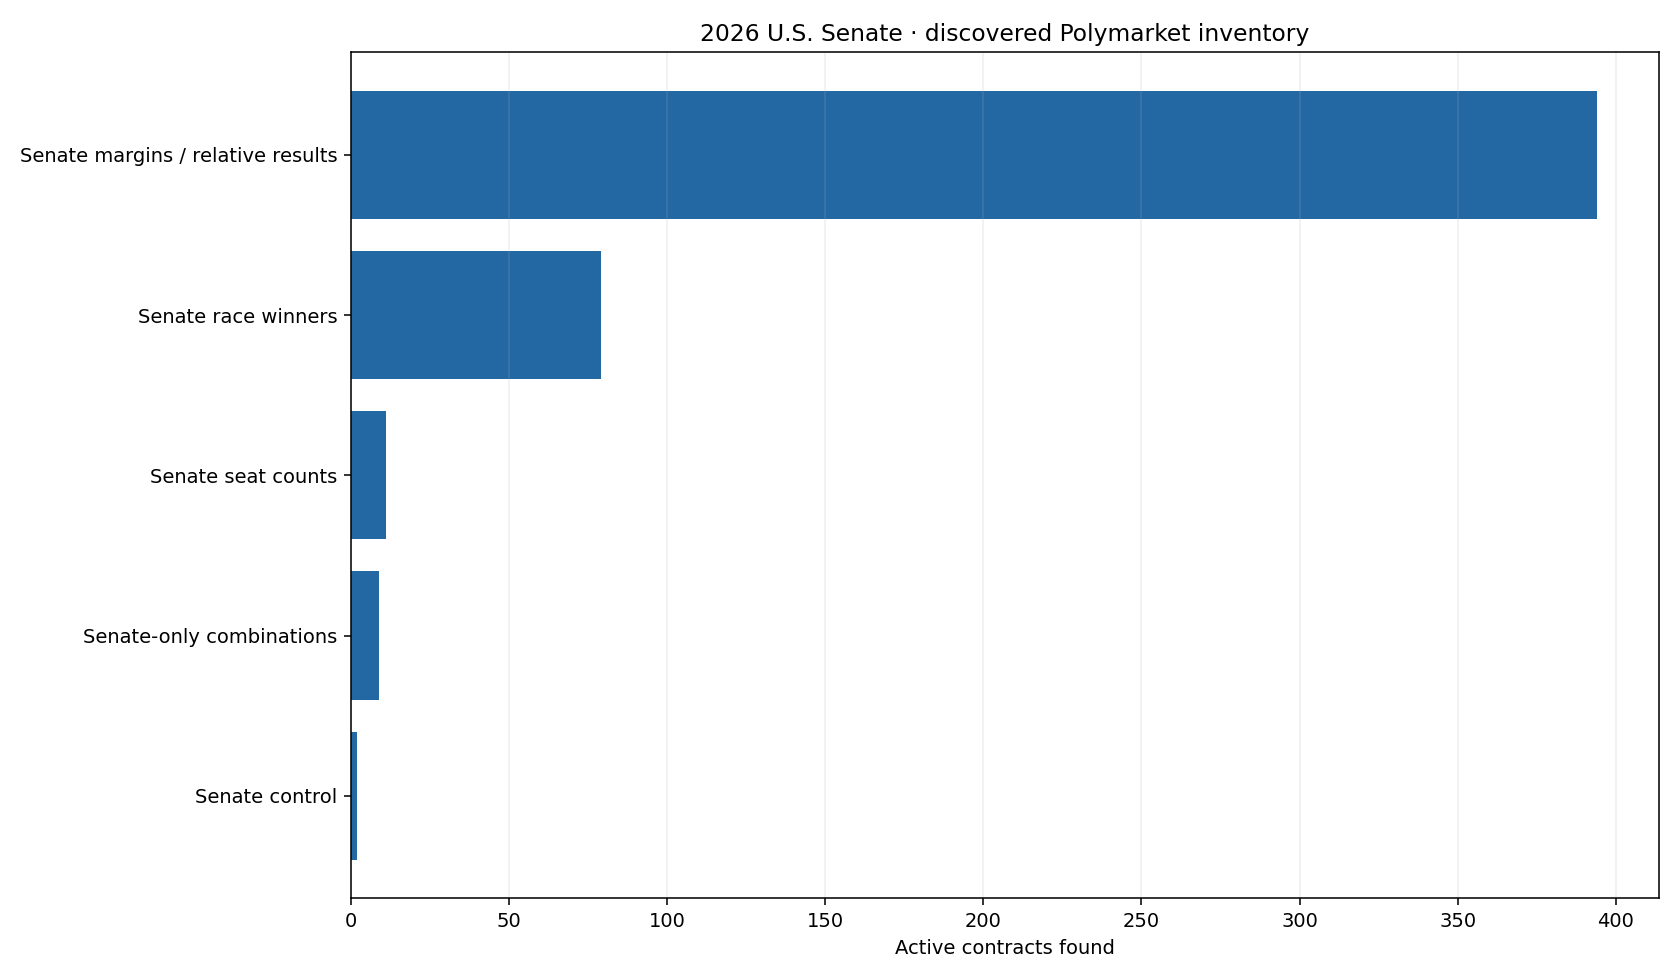

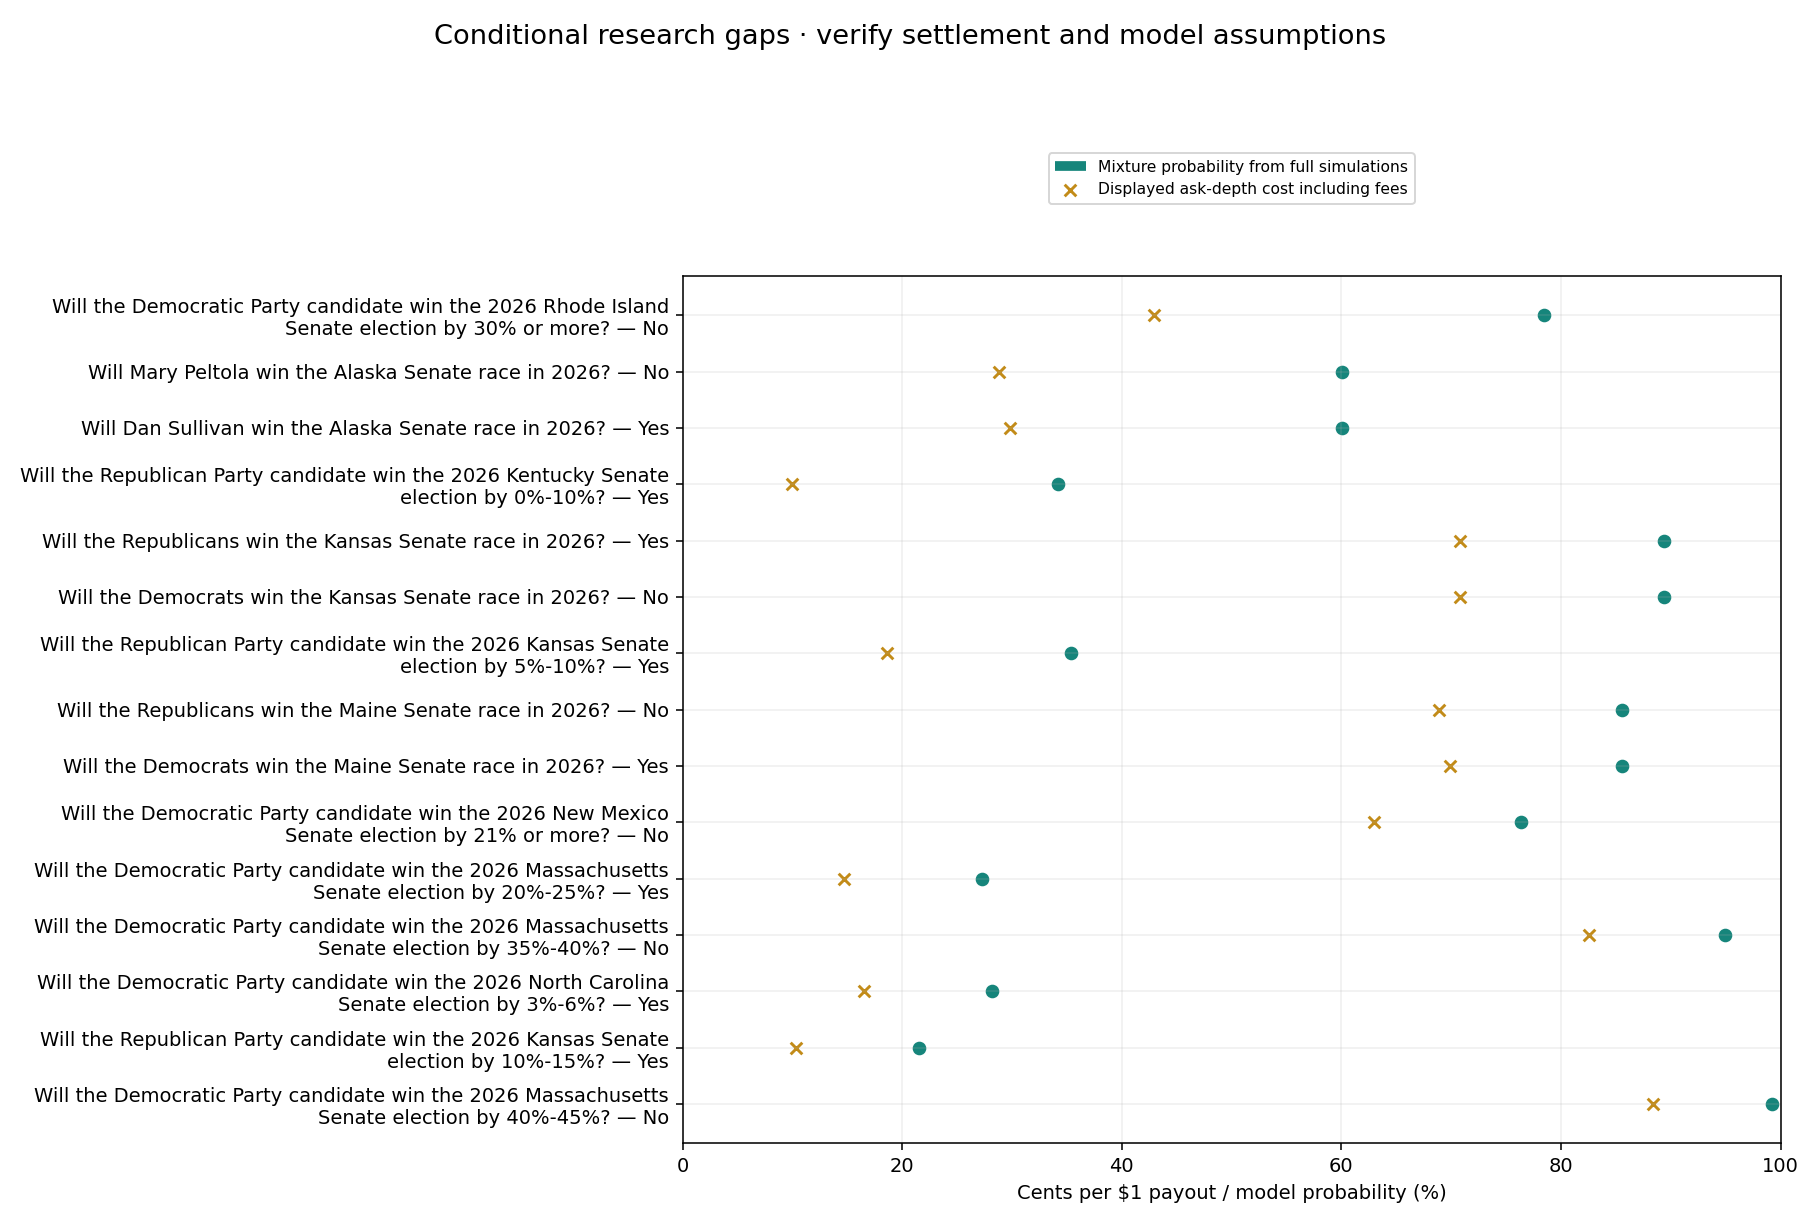

Latest report: /Users/amir/projects/small_models/us_election_2026/outputs/reports/markets/polymarket/report.md
Daily reports: /Users/amir/projects/small_models/us_election_2026/outputs/reports/history


PosixPath('/Users/amir/projects/small_models/us_election_2026/cache/runs/polymarket/20260925T190939.247077Z')

In [13]:
REPORT = poly.save(research)
for path in sorted(REPORT.glob('*.png')):
    display(Image(filename=str(path), width=1100))
print('Latest report:', ROOT/'outputs/reports/markets/polymarket/report.md')
print('Daily reports:', ROOT/'outputs/reports/history')
lab.verify_run(REPORT)